In [8]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import glob
import numpy as np

In [9]:
ea = EventAccumulator("/home/kang/multiagent-quadruped-environment/log/MQE-Curriculum/go1gate/07-17_18-34_1_Leader gate passing(07-17_18-34)_sample_0/run1/logs/average step reward/average step reward/events.out.tfevents.1752802545.kang-iconlab")
ea.Reload()  # loads events from file

print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['average_step_reward'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


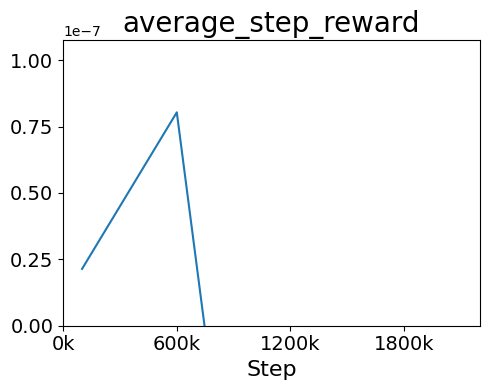

In [10]:
# Collect reward curve - save than reload (easier this way)
curve_img_path = []
for tag in ea.Tags()["scalars"]:
    # if 'Info' in tag:
    reward_curve = []
    for scalar in ea.Scalars(tag):
        reward_curve.append([scalar.step, scalar.value])
    reward_curve = np.array(reward_curve)  
    # name = tag.removeprefix('Info / ')
    name = tag

    plt.figure(figsize=(5, 4))
    plt.plot(reward_curve[:, 0], reward_curve[:, 1])
    plt.xlabel('Step', fontsize=16)
    plt.title(f"{name}", fontsize=20)
    ax = plt.gca()
    ax.set_xlim(left=0)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=False))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k"))
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=False))
    ax.tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout()
    img_path = "test.png"
    plt.savefig(img_path)
    curve_img_path.append(img_path)